In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA ANYLISIS OF MEDICINE DETAILS

In [ ]:
df=pd.read_csv(r'C:\Users\Admin\Downloads\Medicine_Details.csv',encoding='latin1')
print(df.head())

In [ ]:
df.info()

CLEANING AND REMOVING DUPLICATES FROM DATASET

In [ ]:
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
print(df.info())

TOTAL NUMBER OF MEDICINE IN DATA

In [ ]:
print(df['Medicine Name'].count())


NAMES OF THE MANUFACTURER

In [ ]:
manu=np.unique(df['Manufacturer'])
print(manu)

DIFFERENT TYPE OF COMPOSITION

In [ ]:
comp=np.unique(df['Composition'])
print(comp)

MANUFACTURER WHICH HAVE MANY MEDICINE AND VERY FREQUENT

In [ ]:
manufact=df["Manufacturer"].value_counts().idxmax()
print(manufact)

In [ ]:
top_manufacturer=df['Manufacturer'].value_counts().sort_values(ascending=False).head(10)
print(top_manufacturer)

MOST OF COMPOSITION USED

In [ ]:
common_composition=df['Composition'].value_counts().head()
print(common_composition)

In [ ]:
same_composition=df.groupby('Composition')['Medicine Name'].nunique().sort_values(ascending=False)
print(same_composition.head(10))

MOST COMMON DISEASE OR CONDITIONS

In [ ]:
common_disease=df['Uses'].value_counts().head(10)
print(common_disease)

MEDICINCE USE IN MANY CONDITIONS

In [ ]:
df['condition_count']=df['Uses'].str.split(",").str.len()
multi_condition=df[df['condition_count']>1]
print(multi_condition[['Medicine Name','Uses','condition_count']].head(10))

SIDE EFFECT WHICH VERY FREQUENT

In [ ]:
h_side_effect=df['Side_effects'].value_counts().idxmax()
print(h_side_effect)

AVERAGE COUNT FOR MEDICINE SIDE EFFECT

In [ ]:
avg_effect=df.groupby("Medicine Name")['Side_effects'].value_counts().mean()
print(avg_effect)

TOP RATED MEDICINE

In [ ]:
top_rated_medicine=df.sort_values('Excellent Review %',ascending=False)
print(top_rated_medicine['Medicine Name'].head())

POOR RATED MEDICINCES

In [ ]:
poor_rated_medicine=df.sort_values('Poor Review %',ascending=False)
print(poor_rated_medicine['Medicine Name'].head())

DISTRIBUTION OF ALL TYPE OF REVIEW

In [ ]:
review_distribution=df[["Excellent Review %","Average Review %","Poor Review %"]].mean()
print(review_distribution)
review_distribution.plot(kind='pie',autopct='%.2f%%')
plt.title("average distribution of reviews")
plt.show()

AVERAGE REVIEW FOR EACH MANUFACTURER

In [ ]:
review_per_manu=(df.groupby('Manufacturer')['Average Review %'].sum())
review_per_manu=(review_per_manu/review_per_manu.sum())*100
review_per_manu=review_per_manu.sort_values(ascending=False)
print(review_per_manu.head())

BAR GRAPH SHOWN TOP 10 MANUFACTURER WITH THE MEDICINE

In [ ]:
top_manufacturer.plot(kind='bar')
plt.title("top 10 Manufacturer")
plt.xlabel("manufacturer")
plt.ylabel("number of medicine")
plt.xticks(rotation=90)
plt.show()

BAR GRAPH SHOWS THE COMMONLY USE OR FREQUENTLY USE COMPOSITION IN MEDICINE

In [ ]:
top_composition=df['Composition'].value_counts().sort_values(ascending=False).head(10)
top_composition.plot(kind="bar",color='purple')
plt.title("top 10 Composition")
plt.xlabel("composition")
plt.ylabel("number of medicine")
plt.xticks(rotation=90)
plt.show()

SHOWS MOST COMMMON SIDE EFFECT BY MEDICINE

In [ ]:
most_common_side_effect=df['Side_effects'].value_counts().sort_values(ascending=False).head(10)
most_common_side_effect.plot(kind="bar",color="yellow")
plt.title("most common side effect ")
plt.xlabel("side effect")
plt.ylabel("number of times")
plt.xticks(rotation=90)
plt.show()


HISTOGRAM SHOWS THE EXCELLENT REVIEW % WITH RESPECT TO THE MEDICINE COUNT

In [ ]:
plt.hist(df["Excellent Review %"],bins=5,color='orange',edgecolor="black")
plt.title("excellent review % vs medicine")
plt.xlabel("Excellent review %")
plt.ylabel("number of medicine")

plt.show()

HISTOGRAM SHOWS THE POOR REVIEW % WITH RESPECT TO THE  NUMBER OF MEDICINE

In [ ]:
plt.hist(df["Poor Review %"],bins=5,color='brown',edgecolor="black")
plt.title("poor review % vs medicine")
plt.xlabel("poor review %")
plt.ylabel("number of medicine")

plt.show()

BOXPLOT SHOW THE MOST OF COMMON RANGE OF EXCELLENT RATING

In [ ]:

sns.boxplot(data=df,x='Excellent Review %',color='lime')
plt.show()


heatmap correlation with type of review

C:\Users\Admin\AppData\Local\Temp\ipykernel_6892\644741912.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_block = df.corr(method='pearson')


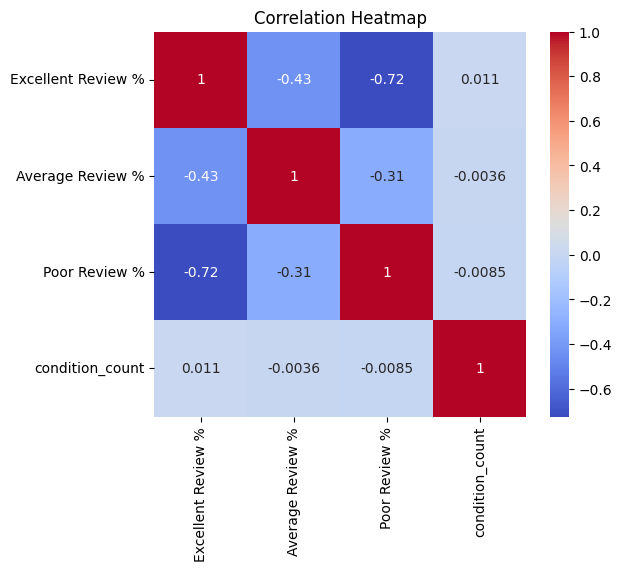

In [46]:
corr_block = df.corr(method='pearson')

plt.figure(figsize=(6,5))
sns.heatmap(corr_block, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#  Insights

After performing exploratory data analysis on the medicine dataset, the following key insights were observed:

1. The dataset contains **11,825 medicine records** from **759 pharmaceutical manufacturers**, representing a diverse range of medicines and healthcare products.

2. **Sun Pharmaceutical Industries Ltd** is the leading manufacturer in the dataset, followed by other major pharmaceutical companies, indicating that a few manufacturers contribute a significant portion of the medicines.

3. The analysis of medicine compositions shows that some active ingredient combinations are prescribed much more frequently than others, while many compositions are unique, highlighting the diversity of pharmaceutical formulations.

4. Customer review analysis reveals that **Excellent Reviews have the highest average percentage**, suggesting that most medicines receive positive feedback from users.

5. The distribution of Excellent and Poor Review percentages indicates that the majority of medicines maintain consistent customer satisfaction, with only a small number of medicines receiving extremely high or low ratings.

6. Side effect analysis identifies several commonly reported side effects shared across multiple medicines, providing useful insights into frequently observed adverse reactions.

7. The box plot highlights the presence of a few outliers in Excellent Review percentages, while most medicines are concentrated within a moderate review range.

8. The correlation heatmap shows a strong negative relationship between **Excellent Review %** and **Poor Review %**, indicating that medicines with higher positive reviews generally receive fewer negative reviews.

9. Overall, the dataset demonstrates a broad pharmaceutical landscape with diverse manufacturers, compositions, therapeutic uses, and customer feedback, making it valuable for healthcare analytics and pharmaceutical market research.

#  Conclusion

This exploratory data analysis of the medicine dataset provided valuable insights into pharmaceutical manufacturers, medicine compositions, customer review patterns, and common side effects. The analysis revealed that a small number of manufacturers contribute a large share of the medicines, while customer feedback is generally positive, with Excellent Reviews outweighing Poor Reviews.

The visualizations—including bar charts, pie charts, histograms, box plots, and a Pearson correlation heatmap—helped uncover meaningful patterns and relationships within the data. In particular, the strong negative correlation between Excellent Review % and Poor Review % indicates that medicines with higher positive ratings tend to receive fewer negative reviews.

Overall, this project demonstrates how Python and data visualization techniques can transform raw healthcare data into actionable insights. The findings can support pharmaceutical market analysis, customer satisfaction assessment, and future healthcare analytics projects. This analysis also provides a solid foundation for advanced applications such as medicine recommendation systems, predictive modeling, and interactive dashboards.